In [19]:
from utils.plotting import *
from utils.metrics import *
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from pathlib import Path
import numpy as np
from tqdm import tqdm

from utils.metrics import compute_monotonic_trajectory_tortuosity, compute_monotonic_depth_spearman, compute_transition_branch_connectivity, compute_directional_branch_separability, compute_transition_type_consistency


In [ ]:
# FOR AGENTS -------------------------
window_size = 20

z = 16
h = 64
beta = "1e-3"
sparse_beta = "0.1"
# runs_folder = f"runs_{window_size}_window_agent_rew_p_0.0"
ONLINE_LR_PRIOR="1e-3"
ONLINE_LR_POSTERIOR="1e-3"
ONLINE_LR_OTHER="1e-3"

mouse_sources = {}
for rew_p in ["0.0","0.005", "0.01", "0.015", "0.02", "0.025", "0.03", "0.035", "0.04", "0.045", "0.05","0.055", "0.06", "0.065", "0.07", "0.075", "0.08", "0.085", "0.09", "0.095", "0.1"]:
    for seed in range(0, 30):
        runs_folder = f"REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/{seed}"
        mouse_sources[f'Agent_{seed}_{rew_p}']={"content_path": f"../outdata/A1a-tf", "metrics_dir": f"../{runs_folder}"}

    

In [ ]:
# FOR MICE ---------------------------------------------------
window_size = 20

z = 16
h = 64
beta = "1e-3"
sparse_beta = "0.1"
runs_folder = f"runs_{window_size}_window"
ONLINE_LR_PRIOR="1e-3"
ONLINE_LR_POSTERIOR="1e-3"
ONLINE_LR_OTHER="1e-3"

mouse_sources = {}
for mouse in ["A1a", "A1b", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "C1", "C3", "C6", "C7", "C8", "C9", "D3", "D4", "D5", "D7", "D7a", "D7b", "D8", "D9", "D9a", "D9b", "F2a", "F2b"]:
    mouse_sources[mouse]={"content_path": f"../outdata/{mouse}-tf", "metrics_dir": f"../{runs_folder}/water_sparsity_{sparse_beta}_hdim_{h}_zdim_{z}_beta{beta}_lr{ONLINE_LR_PRIOR}_{ONLINE_LR_POSTERIOR}_{ONLINE_LR_OTHER}/{mouse}"}

In [ ]:
import os
import pickle
from tqdm import tqdm

os.makedirs("metrics_agent", exist_ok=True)

group_fracs = [
    (0.0, 0.1), (0.1, 0.2), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.0)
]

# res_scores_arc_chord = {}
# res_scores_depth = {}
# res_scores_local_transition_consistency = {}

with open(f"metrics_agent/res_scores_depth_all.pkl", "rb") as f:
    res_scores_depth = pickle.load(f)

with open(f"metrics_agent/res_scores_local_transition_consistency_all.pkl", "rb") as f:
    res_scores_local_transition_consistency = pickle.load(f)

with open(f"metrics_agent/res_scores_arc_chord_all.pkl", "rb") as f:
    res_scores_arc_chord = pickle.load(f)
    

for group_frac in group_fracs:
    group_frac_name = f"{group_frac[0]}_{group_frac[1]}"

    for mouse in tqdm(mouse_sources, desc=f"group_frac={group_frac_name}"):

        key = f"{mouse}__group_frac_{group_frac_name}"

        # 1. Arc chord ratio
        arc_chord_ratio_score = compute_monotonic_trajectory_tortuosity(
            mouse_sources=mouse_sources,
            mouse=mouse,
            z_key="z_p",
            group_frac=group_frac,
            direction="both",
        )

        res_scores_arc_chord[key] = arc_chord_ratio_score

        # 2. Depth alignment
        depth_score = compute_monotonic_depth_spearman(
            mouse_sources=mouse_sources,
            mouse=mouse,
            z_key="z_p",
            group_frac=group_frac,
            direction="both",
        )

        res_scores_depth[key] = depth_score

        # 3. Local transition consistency
        transition_consistency_score = compute_transition_type_consistency_in_out(
            mouse_sources=mouse_sources,
            mouse=mouse,
            z_key="z_p",
            group_frac=group_frac,
            k=5,
            return_by_direction=False,
        )

        res_scores_local_transition_consistency[key] = transition_consistency_score


with open("metrics_agent/res_scores_arc_chord_all.pkl", "wb") as f:
    pickle.dump(res_scores_arc_chord, f)

with open("metrics_agent/res_scores_depth_all.pkl", "wb") as f:
    pickle.dump(res_scores_depth, f)

with open("metrics_agent/res_scores_local_transition_consistency_all.pkl", "wb") as f:
    pickle.dump(res_scores_local_transition_consistency, f)

group_frac=0.2_0.3: 100%|██████████| 420/420 [1:11:10<00:00, 10.17s/it]


# agent plot

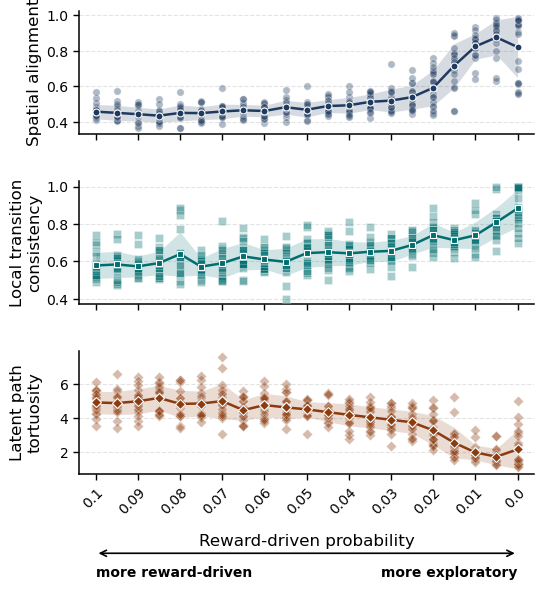

In [45]:
import os
import pickle
import re
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Load metric dicts
# -----------------------
group_frac_to_plot = (0.2, 0.3)

with open("metrics_agent/res_scores_depth_all.pkl", "rb") as f:
    res_spatial = pickle.load(f)

with open("metrics_agent/res_scores_local_transition_consistency_all.pkl", "rb") as f:
    res_transition = pickle.load(f)

with open("metrics_agent/res_scores_arc_chord_all.pkl", "rb") as f:
    res_arc = pickle.load(f)

# -----------------------
# Config
# -----------------------
os.makedirs("figs", exist_ok=True)

color_spatial    = "#1F3A5F"
color_transition = "#006D6F"
color_arc        = "#8C3B0E"


# -----------------------
# Parse key:
# Agent_{seed}_{rew_p}__group_frac_{lo}_{hi}
# -----------------------
def parse_all_key(key):
    """
    Example key:
        Agent_10_0.0__group_frac_0.2_0.3

    Returns:
        agent, seed, rew_p, group_frac
    """
    match = re.match(
        r"^(Agent_(\d+)_(.+?))__group_frac_([0-9.]+)_([0-9.]+)$",
        key,
    )

    if match is None:
        raise ValueError(f"Could not parse key: {key}")

    agent = match.group(1)
    seed = int(match.group(2))
    rew_p = float(match.group(3))
    group_frac = (float(match.group(4)), float(match.group(5)))

    return agent, seed, rew_p, group_frac


def get_score_value(x):
    """
    Handles both:
        score
    and old style:
        [score]
    """
    if isinstance(x, list):
        return float(x[-1])
    return float(x)


# -----------------------
# Keep only selected group_frac
# and only keys present in all 3 dicts
# -----------------------
common_keys = set(res_spatial) & set(res_transition) & set(res_arc)

keys = []
for key in common_keys:
    _, _, _, gf = parse_all_key(key)

    if np.allclose(gf, group_frac_to_plot):
        keys.append(key)

keys = sorted(
    keys,
    key=lambda k: (parse_all_key(k)[2], parse_all_key(k)[1]),
)

rew_ps = sorted({parse_all_key(k)[2] for k in keys})
x = np.array(rew_ps)


# -----------------------
# Group values by rew_p across seeds
# -----------------------
def grouped_metric(res_dict, keys, rew_ps):
    grouped = {rew_p: [] for rew_p in rew_ps}

    for key in keys:
        _, _, rew_p, _ = parse_all_key(key)
        grouped[rew_p].append(get_score_value(res_dict[key]))

    means = np.array([np.nanmean(grouped[rew_p]) for rew_p in rew_ps])
    stds = np.array([
        np.nanstd(grouped[rew_p], ddof=1) if len(grouped[rew_p]) > 1 else 0.0
        for rew_p in rew_ps
    ])

    return means, stds, grouped


spatial_mean, spatial_std, spatial_grouped = grouped_metric(res_spatial, keys, rew_ps)
transition_mean, transition_std, transition_grouped = grouped_metric(res_transition, keys, rew_ps)
arc_mean, arc_std, arc_grouped = grouped_metric(res_arc, keys, rew_ps)


# -----------------------
# Tick formatting
# -----------------------
def is_multiple_of_001(val, atol=1e-10):
    return np.isclose(val / 0.01, np.round(val / 0.01), atol=atol)

xticks_to_show = [val for val in x if np.isclose(val, 0.0) or is_multiple_of_001(val)]

def format_rew_tick(val):
    if np.isclose(val, 0.0):
        return "0.0"
    elif val < 0.1:
        return f"{val:.2f}"
    else:
        return f"{val:.2f}".rstrip("0").rstrip(".")

xtick_labels = [format_rew_tick(val) for val in xticks_to_show]


# -----------------------
# Figure: 3 vertical panels
# -----------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(6.8, 7.6),
    sharex=True,
    gridspec_kw={"hspace": 0.38},
)

plot_specs = [
    (axes[0], spatial_mean,    spatial_std,    spatial_grouped,    color_spatial,    "o", "Spatial alignment"),
    (axes[1], transition_mean, transition_std, transition_grouped, color_transition, "s", "Local transition\nconsistency"),
    (axes[2], arc_mean,        arc_std,        arc_grouped,        color_arc,        "D", "Latent path\ntortuosity"),
]

for i, (ax, mean_y, std_y, grouped, color, marker, ylabel) in enumerate(plot_specs):

    # individual seed points
    for rew_p in rew_ps:
        ys = np.array(grouped[rew_p], dtype=float)
        xs = np.full_like(ys, rew_p, dtype=float)

        ax.scatter(
            xs, ys,
            color=color,
            s=28,
            marker=marker,
            alpha=0.35,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
            clip_on=False,
        )

    # mean line
    ax.plot(
        x, mean_y,
        color=color,
        linewidth=1.8,
        marker=marker,
        markersize=5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=4,
        clip_on=False,
    )

    # std shadow
    ax.fill_between(
        x,
        mean_y - std_y,
        mean_y + std_y,
        color=color,
        alpha=0.18,
        linewidth=0,
        zorder=2,
    )

    ax.set_ylabel(ylabel, color="black")
    ax.yaxis.set_label_coords(-0.08, 0.5)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelcolor="black")
    ax.tick_params(axis="both", labelsize=10)

    if i < 2:
        ax.tick_params(axis="x", which="both", labelbottom=False)


# -----------------------
# Shared x-axis: large rew_p -> low rew_p
# -----------------------
x_range = x.max() - x.min()
x_pad = 0.04 * x_range if x_range > 0 else 0.002

axes[-1].set_xlim(x.max() + x_pad, x.min() - x_pad)

axes[-1].set_xticks(xticks_to_show)
axes[-1].set_xticklabels(
    xtick_labels,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

axes[-1].tick_params(axis="x", pad=4)
axes[-1].set_xlabel("Reward-driven probability", labelpad=12)


# -----------------------
# Direction labels + double arrow
# -----------------------
y_side_labels = -0.8
y_arrow = -0.64

axes[-1].annotate(
    "more reward-driven",
    xy=(x.max(), y_side_labels),
    xycoords=("data", "axes fraction"),
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    annotation_clip=False,
)

axes[-1].annotate(
    "more exploratory",
    xy=(x.min(), y_side_labels),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="center",
    fontsize=10,
    fontweight="bold",
    annotation_clip=False,
)

axes[-1].annotate(
    "",
    xy=(x.min(), y_arrow),
    xytext=(x.max(), y_arrow),
    xycoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="<->", lw=1.2, color="black"),
    annotation_clip=False,
)

plt.subplots_adjust(
    left=0.30,
    right=0.97,
    top=0.98,
    bottom=0.37,
    hspace=0.38,
)

gf_name = f"{group_frac_to_plot[0]}_{group_frac_to_plot[1]}"
plt.savefig(f"figs/agent_metrics_by_rew_p_{gf_name}.svg", format="svg", bbox_inches="tight")

plt.show()

# mice plot

In [46]:
exploration_level = {
    "D8": 0.939,
    "D5": 0.936,
    "C6": 0.935,
    "D7a": 0.935,
    "F2a": 0.932,
    "D4": 0.932,
    "C1": 0.931,
    "A1a": 0.930,
    "D7": 0.930,
    "B5": 0.929,
    "F2b": 0.927,
    "B2": 0.925,
    "D3": 0.922,
    "B4": 0.920,
    "D9": 0.918,
    "B1": 0.915,
    "B6": 0.915,
    "D7b": 0.913,
    "C3": 0.913,
    "A1b": 0.910,
    "C9": 0.909,
    "B3": 0.904,
    "C8": 0.903,
    "C7": 0.898,
    "D9b": 0.895,
    "B7": 0.894,
    "D9a": 0.891,
}

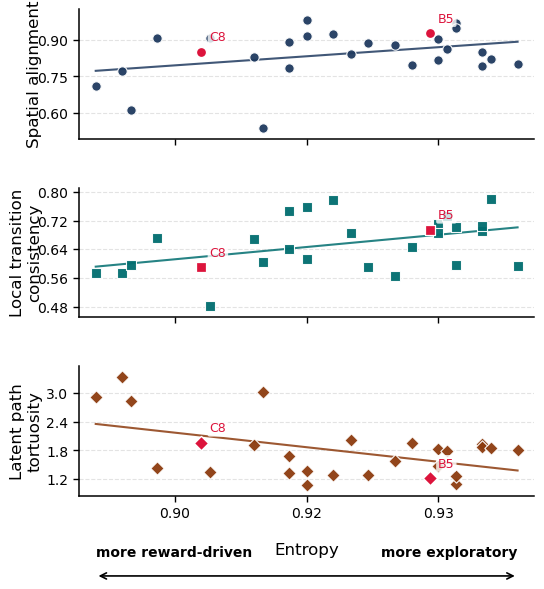

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# -----------------------
# Load metric dicts
# -----------------------
with open("figs/real_mice_res_scores_depth.pkl", "rb") as f:
    res_spatial = pickle.load(f)

with open("figs/real_mice_res_scores_local_transition_consistency.pkl", "rb") as f:
    res_transition = pickle.load(f)

with open("figs/real_mice_res_scores_arc_chord.pkl", "rb") as f:
    res_arc = pickle.load(f)

# -----------------------
# Config
# -----------------------
color_spatial    = "#1F3A5F"
color_transition = "#006D6F"
color_arc        = "#8C3B0E"

highlight_mice = {"B5", "C8"}

# -----------------------
# Keep only mice present everywhere
# -----------------------
mice = sorted(
    set(exploration_level)
    & set(res_spatial)
    & set(res_transition)
    & set(res_arc),
    key=lambda m: exploration_level[m],
)

x = np.array([exploration_level[m] for m in mice], dtype=float)

spatial_y    = np.array([res_spatial[m][-1] for m in mice], dtype=float)
transition_y = np.array([res_transition[m][-1] for m in mice], dtype=float)
arc_y        = np.array([res_arc[m][-1] for m in mice], dtype=float)

# sort by entropy: reward-driven -> exploratory
order = np.argsort(x)
x = x[order]
mice = [mice[i] for i in order]

spatial_y    = spatial_y[order]
transition_y = transition_y[order]
arc_y        = arc_y[order]

# -----------------------
# Figure: 3 vertical panels
# -----------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(6.8, 7.6),
    sharex=True,
    gridspec_kw={"hspace": 0.38}
)

plot_specs = [
    (axes[0], spatial_y,    color_spatial,    "o", "Spatial alignment"),
    (axes[1], transition_y, color_transition, "s", "Local transition\nconsistency"),
    (axes[2], arc_y,        color_arc,        "D", "Latent path\ntortuosity"),
]

x_range = x.max() - x.min()
x_pad = 0.04 * x_range if x_range > 0 else 0.01
x_left = x.min() - x_pad
x_right = x.max() + x_pad

for i, (ax, y, color, marker, ylabel) in enumerate(plot_specs):
    # main scatter
    ax.scatter(
        x, y,
        color=color,
        s=46,
        marker=marker,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95,
        zorder=3,
        clip_on=False,   # prevents clipping at edges
    )

    # linear fit
    coef = np.polyfit(x, y, deg=1)
    slope = coef[0]

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = np.polyval(coef, x_fit)

    ax.plot(
        x_fit, y_fit,
        color=color,
        linewidth=1.5,
        alpha=0.85,
        zorder=2,
    )

    # highlight selected mice
    for mouse in highlight_mice:
        if mouse in mice:
            idx = mice.index(mouse)

            ax.scatter(
                x[idx], y[idx],
                s=52,
                color="crimson",
                marker=marker,
                edgecolor="white",
                linewidth=0.9,
                zorder=5,
                clip_on=False,
            )

            if x[idx] > x.min() + 0.8 * (x.max() - x.min()):
                xytext = (-8, 6)
                ha = "right"
            else:
                xytext = (6, 6)
                ha = "left"

            ax.annotate(
                mouse,
                xy=(x[idx], y[idx]),
                xytext=xytext,
                textcoords="offset points",
                fontsize=9,
                ha=ha,
                va="bottom",
                color="crimson",
                zorder=6,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
            )

    
    ax.set_ylabel(ylabel, color="black")
    ax.yaxis.set_label_coords(-0.08, 0.5)

    # axis style
    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelcolor="black")
    ax.tick_params(axis="both", labelsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.margins(y=0.10)

    if i < 2:
        ax.tick_params(axis="x", which="both", labelbottom=False)

# -----------------------
# Shared x-axis
# -----------------------
axes[-1].set_xlim(x_left, x_right)
axes[-1].xaxis.set_major_locator(MaxNLocator(nbins=4))
axes[-1].xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axes[-1].set_xlabel("Entropy", labelpad=16)

# -----------------------
# Direction labels + double arrow
# hierarchy:
# x ticks -> xlabel -> side labels -> arrow
# -----------------------
y_side_labels = -0.44
y_arrow = -0.62

axes[-1].annotate(
    "more reward-driven",
    xy=(x.min(), y_side_labels),
    xycoords=("data", "axes fraction"),
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    annotation_clip=False,
)

axes[-1].annotate(
    "more exploratory",
    xy=(x.max(), y_side_labels),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="center",
    fontsize=10,
    fontweight="bold",
    annotation_clip=False,
)

axes[-1].annotate(
    "",
    xy=(x.max(), y_arrow),
    xytext=(x.min(), y_arrow),
    xycoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="<->", lw=1.2, color="black"),
    annotation_clip=False,
)

plt.subplots_adjust(
    left=0.30,
    right=0.97,
    top=0.98,
    bottom=0.34,
    hspace=0.38,
)

plt.savefig("figs/real_mice_metrics.svg", format="svg", bbox_inches="tight")
# plt.savefig("figs/real_mice_metrics.pdf", format="pdf", bbox_inches="tight")

plt.show()